# Northstar Retail — Local Validation Demo

This notebook uses the packaged deterministic fixture and pandas Gold parity harness. It demonstrates locally verified structure and reconciliation without claiming that SQL Server, PostgreSQL, Databricks, or Power BI ran in this environment.

![Architecture](../docs/images/overall_architecture.svg)

In [1]:
from pathlib import Path
import json
import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path("..") if Path.cwd().name == "notebooks" else Path(".")
SAMPLE = ROOT / "datasets" / "sample"
GOLD = ROOT / "datasets" / "demo_gold"
manifest = json.loads((GOLD / "gold_manifest.json").read_text())
manifest_summary = {k: manifest[k] for k in ["batch_id", "quality_status", "required_checks", "failed_required_checks"]}
manifest_summary

{'batch_id': 'GEN-20260815T120000Z-bcb100dcba34',
 'quality_status': 'PASS',
 'required_checks': 70,
 'failed_required_checks': 0}

## Gold table inventory

In [2]:
table_inventory = pd.DataFrame([
    {"table": row["table_name"], "rows": row["rows"], "sha256_prefix": row["sha256"][:12]}
    for row in manifest["tables"]
]).sort_values("table")
table_inventory

,table,rows,sha256_prefix
8,dim_campaign,9,7bf68ddb8a23
7,dim_channel,9,654d21122fe8
1,dim_customer,58,4d8cd027f886
0,dim_date,3654,5667b82bf8c0
4,dim_employee,21,68f2758ceebc
2,dim_product,31,b0e3ebff8605
6,dim_promotion,4,dffe50d40084
3,dim_store,6,cd90360315cb
5,dim_supplier,9,62b8c9412910
11,fact_inventory_snapshot,50,f1f7ef604294


## Reconciled KPI sample

In [3]:
sales = pd.read_csv(GOLD / "fact_sales.csv")
returns = pd.read_csv(GOLD / "fact_returns.csv")
shipments = pd.read_csv(GOLD / "fact_shipments.csv")
sessions = pd.read_csv(GOLD / "fact_web_sessions.csv")
spend = pd.read_csv(GOLD / "fact_marketing_spend.csv")

kpis = pd.Series({
    "Net Sales": sales.net_sales_amount.sum(),
    "Gross Profit": sales.gross_profit_amount.sum(),
    "Orders": sales.order_id.nunique(),
    "Valid Sales Lines": len(sales),
    "Returned Units": returns.return_quantity.sum(),
    "On-Time Delivery Rate": shipments.on_time_flag.mean(),
    "Web Sessions": sessions.session_count.sum(),
    "Conversion Rate": sessions.converted_flag.mean(),
    "Marketing Spend": spend.spend_amount.sum(),
})
kpis.to_frame("value")

,value
Net Sales,28325.940000
Gross Profit,13788.970000
Orders,198.000000
Valid Sales Lines,397.000000
Returned Units,33.000000
On-Time Delivery Rate,0.477064
Web Sessions,300.000000
Conversion Rate,0.036667
Marketing Spend,123951.440000


## Source-to-Gold reconciliation

In [4]:
reconciliation = pd.DataFrame(json.loads((GOLD / "reconciliation_results.json").read_text()))
reconciliation

,batch_id,check_name,source_value,target_value,difference_value,status
0,GEN-20260815T120000Z-bcb100dcba34,source_to_gold_valid_sales_rows,397.00,397.00,0.0,PASS
1,GEN-20260815T120000Z-bcb100dcba34,source_to_gold_net_sales,28325.94,28325.94,-0.0,PASS


## Monthly net-sales trend

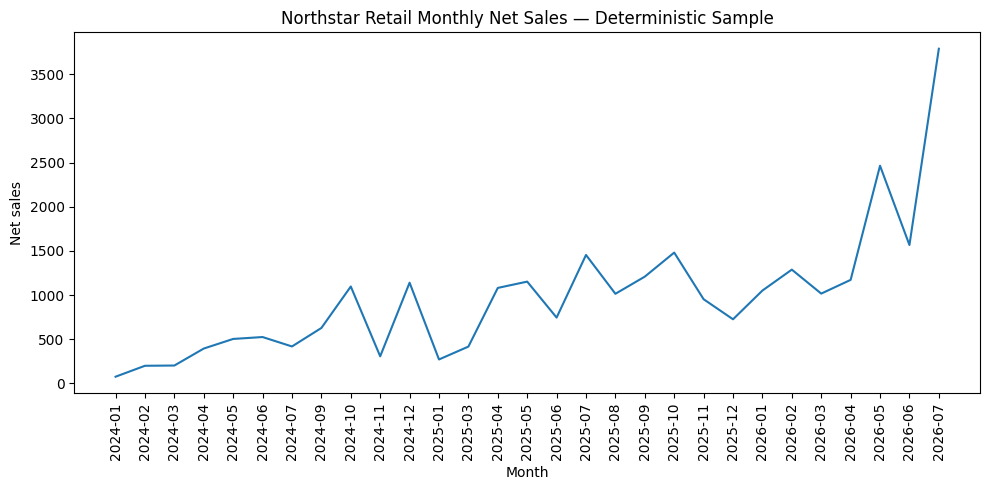

In [5]:
dates = pd.read_csv(GOLD / "dim_date.csv", parse_dates=["full_date"])
monthly = (sales.merge(dates[["date_key", "full_date"]], left_on="order_date_key", right_on="date_key")
           .assign(month=lambda d: d.full_date.dt.to_period("M").astype(str))
           .groupby("month", as_index=False).net_sales_amount.sum())
plt.figure(figsize=(10, 5))
plt.plot(monthly["month"], monthly["net_sales_amount"])
plt.xticks(rotation=90)
plt.xlabel("Month")
plt.ylabel("Net sales")
plt.title("Northstar Retail Monthly Net Sales — Deterministic Sample")
plt.tight_layout()
plt.show()

## Interpretation boundary

These values are generated from fictional data and are evidence that the local implementation is internally consistent. They are not real company performance and are not evidence that an external Databricks Job, SQL Server publication, or Power BI refresh succeeded.